# Go Academics — Mission & Problem Statement

## Mission Statement
Creating an offline, machine learning-driven, early warning software system (**Go Academics**) to help secondary school teachers in Rwanda with timely intervention by predicting students’ risk of academic failure and thereby enhancing learning outcomes.

---

## Problem Statement

Most Rwandan secondary schools — especially in rural areas — lack reliable internet and Learning Management Systems, making existing predictive analytics tools unusable in these contexts.

Current tools are also reactive, not proactive: they report performance at the end of term, too late for meaningful intervention. They are built for administrators, not teachers.

**Go Academics** addresses this by providing an offline, teacher-centered early warning system that uses simple, readily available data — attendance, continuous assessment scores, and study hours — to identify at-risk students early, enabling timely intervention regardless of infrastructure.

---

# GoAcademics â€” RL Summative (Kaggle Version)
**Student:** Ngamije Davy  
**Project:** Go Academics â€” Offline Early Warning System for Rwandan Secondary Schools  

> Run this notebook on Kaggle with **GPU accelerator** enabled for faster training.
> All outputs (models, CSVs, plots) are saved to `/kaggle/working/` and can be downloaded.

---
### Sections
1. Install Dependencies
2. Write Environment Files
3. Environment Walkthrough
4. Random Agent Demo
5. DQN Training (10 runs)
6. REINFORCE Training (10 runs)
7. PPO Training (10 runs)
8. A2C Training (10 runs)
9. Results Analysis & Plots
10. Run Best Agent

## 1. Install Dependencies

In [1]:
!pip install stable-baselines3[extra] gymnasium pygame shimmy --quiet
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.5 MB/s eta 0:00:00
Dependencies installed.


## 2. Write Environment Files
Since Kaggle has no access to your local files, we write the environment code directly into `/kaggle/working/environment/`.

In [2]:
import os
os.makedirs('/kaggle/working/environment', exist_ok=True)

# Write __init__.py so Python treats it as a package
with open('/kaggle/working/environment/__init__.py', 'w') as f:
    f.write('')

print('Created /kaggle/working/environment/')

Created /kaggle/working/environment/


In [3]:
%%writefile /kaggle/working/environment/custom_env.py
"""
GoAcademics - Custom Multi-Agent Gymnasium Environment
-------------------------------------------------------
Each 'agent' represents a student in a Rwandan secondary school classroom.
The RL agent (teacher/system) observes all students and selects one
intervention per student per timestep to maximise end-of-term pass rates.

Observation per student (6 features):
    [attendance_rate, ca_score, study_hours,
     assignment_completion, term_week, risk_level]

Actions (discrete, 6 per student):
    0 - No intervention
    1 - Send attendance alert to parent
    2 - Assign peer tutoring
    3 - One-on-one teacher counselling
    4 - Extra CA practice assignment
    5 - Escalate to school administration
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces

N_ACTIONS     = 6
TERM_LENGTH   = 13
PASS_CA       = 50.0
PASS_ATTENDANCE   = 0.70
DROPOUT_ATTENDANCE = 0.20
DROPOUT_WEEKS = 3


class StudentState:
    def __init__(self, rng):
        self.rng = rng
        self.reset()

    def reset(self):
        self.attendance_rate        = float(self.rng.uniform(0.50, 1.00))
        self.ca_score               = float(self.rng.uniform(20.0, 80.0))
        self.study_hours            = float(self.rng.uniform(0.5, 6.0))
        self.assignment_completion  = float(self.rng.uniform(0.40, 1.00))
        self.risk_level             = self._compute_risk()
        self.low_attendance_streak  = 0
        self.dropped_out            = False
        self.passed                 = False

    def _compute_risk(self):
        score = 0
        if self.attendance_rate < 0.60:       score += 1
        if self.ca_score < 40:                score += 1
        if self.study_hours < 2.0:            score += 1
        if self.assignment_completion < 0.60: score += 1
        return 2 if score >= 3 else (1 if score >= 1 else 0)

    def to_obs(self, term_week):
        return np.array([
            self.attendance_rate,
            self.ca_score / 100.0,
            self.study_hours / 12.0,
            self.assignment_completion,
            term_week / TERM_LENGTH,
            self.risk_level / 2.0,
        ], dtype=np.float32)

    def step(self, action, rng):
        old_risk = self.risk_level
        reward   = 0.0

        if action == 0:
            if self.risk_level == 2: reward -= 1.0
            self.ca_score        += float(rng.uniform(-1.0, 1.5))
            self.attendance_rate += float(rng.uniform(-0.02, 0.01))
        elif action == 1:
            self.attendance_rate += float(rng.uniform(0.02, 0.08))
            self.ca_score        += float(rng.uniform(-0.5, 1.0))
        elif action == 2:
            self.ca_score    += float(rng.uniform(1.0, 4.0))
            self.study_hours += float(rng.uniform(0.2, 0.8))
        elif action == 3:
            self.ca_score        += float(rng.uniform(1.5, 5.0))
            self.attendance_rate += float(rng.uniform(0.01, 0.05))
            self.study_hours     += float(rng.uniform(0.1, 0.5))
        elif action == 4:
            self.ca_score              += float(rng.uniform(2.0, 6.0))
            self.assignment_completion += float(rng.uniform(0.02, 0.08))
        elif action == 5:
            if self.risk_level < 2:
                reward -= 2.0
            else:
                self.attendance_rate += float(rng.uniform(0.03, 0.10))
                self.ca_score        += float(rng.uniform(1.0, 4.0))
                self.study_hours     += float(rng.uniform(0.2, 0.6))

        self.ca_score              = float(np.clip(self.ca_score, 0.0, 100.0))
        self.attendance_rate       = float(np.clip(self.attendance_rate, 0.0, 1.0))
        self.study_hours           = float(np.clip(self.study_hours, 0.0, 12.0))
        self.assignment_completion = float(np.clip(self.assignment_completion, 0.0, 1.0))

        new_risk = self._compute_risk()
        self.risk_level = new_risk

        if new_risk < old_risk:   reward += 10.0
        elif new_risk > old_risk: reward -= 5.0
        if self.ca_score > (PASS_CA - 5): reward += 2.0

        if self.attendance_rate < DROPOUT_ATTENDANCE:
            self.low_attendance_streak += 1
        else:
            self.low_attendance_streak = 0

        if self.low_attendance_streak >= DROPOUT_WEEKS:
            self.dropped_out = True
            reward -= 20.0

        if self.ca_score >= PASS_CA and self.attendance_rate >= PASS_ATTENDANCE:
            self.passed = True
            reward += 20.0

        return reward


class GoAcademicsEnv(gym.Env):
    """Multi-student classroom environment."""
    metadata = {'render_modes': ['human', 'rgb_array'], 'render_fps': 4}

    def __init__(self, n_students=10, render_mode=None, seed=None):
        super().__init__()
        self.n_students  = n_students
        self.render_mode = render_mode
        self.rng         = np.random.default_rng(seed)
        self.observation_space = spaces.Box(
            np.zeros(n_students * 6, dtype=np.float32),
            np.ones(n_students * 6, dtype=np.float32),
            dtype=np.float32,
        )
        self.action_space = spaces.MultiDiscrete([N_ACTIONS] * n_students)
        self.students  = [StudentState(np.random.default_rng(i)) for i in range(n_students)]
        self.term_week = 1
        self.window = None
        self.clock  = None
        self.window_size = (1100, 600)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        for s in self.students:
            s.rng = np.random.default_rng(self.rng.integers(0, 2**31))
            s.reset()
        self.term_week = 1
        return self._get_obs(), self._get_info()

    def step(self, actions):
        total_reward = 0.0
        for student, action in zip(self.students, actions):
            if not student.dropped_out:
                total_reward += student.step(int(action), self.rng)
        self.term_week += 1
        terminated = self._check_terminated()
        truncated  = self.term_week > TERM_LENGTH
        return self._get_obs(), total_reward, terminated, truncated, self._get_info()

    def _get_obs(self):
        return np.concatenate([s.to_obs(self.term_week) for s in self.students]).astype(np.float32)

    def _get_info(self):
        return {
            'term_week':  self.term_week,
            'n_passed':   sum(s.passed      for s in self.students),
            'n_dropped':  sum(s.dropped_out for s in self.students),
            'risk_counts': {
                'low':    sum(1 for s in self.students if s.risk_level == 0),
                'medium': sum(1 for s in self.students if s.risk_level == 1),
                'high':   sum(1 for s in self.students if s.risk_level == 2),
            },
            'avg_ca':         float(np.mean([s.ca_score         for s in self.students])),
            'avg_attendance': float(np.mean([s.attendance_rate  for s in self.students])),
        }

    def _check_terminated(self):
        return all(s.passed or s.dropped_out for s in self.students)

    def render(self): pass
    def close(self): pass


class SingleStudentEnv(gym.Env):
    """Single-student env for DQN / VecEnv."""
    metadata = {'render_modes': [], 'render_fps': 4}

    def __init__(self, seed=None):
        super().__init__()
        self.rng = np.random.default_rng(seed)
        self.observation_space = spaces.Box(
            low=np.zeros(6, dtype=np.float32),
            high=np.ones(6, dtype=np.float32),
            dtype=np.float32,
        )
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.student   = StudentState(np.random.default_rng(self.rng.integers(0, 2**31)))
        self.term_week = 1

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.student.rng = np.random.default_rng(self.rng.integers(0, 2**31))
        self.student.reset()
        self.term_week = 1
        return self.student.to_obs(self.term_week), {}

    def step(self, action):
        reward = self.student.step(int(action), self.rng)
        self.term_week += 1
        terminated = self.student.passed or self.student.dropped_out
        truncated  = self.term_week > TERM_LENGTH
        info = {
            'term_week':  self.term_week,
            'ca_score':   self.student.ca_score,
            'attendance': self.student.attendance_rate,
            'risk_level': self.student.risk_level,
            'passed':     self.student.passed,
            'dropped_out':self.student.dropped_out,
        }
        return self.student.to_obs(self.term_week), reward, terminated, truncated, info

    def render(self): pass
    def close(self): pass

Writing /kaggle/working/environment/custom_env.py


In [4]:
# Add /kaggle/working to sys.path so imports work
import sys
sys.path.insert(0, '/kaggle/working')

import os, csv, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
from IPython.display import display

from environment.custom_env import GoAcademicsEnv, SingleStudentEnv

# â”€â”€ output directories â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
WORK      = '/kaggle/working'
DQN_DIR   = f'{WORK}/models/dqn'
PG_DIR    = f'{WORK}/models/pg'

for path in [DQN_DIR, f'{DQN_DIR}/best_model',
             f'{PG_DIR}/reinforce', f'{PG_DIR}/ppo',
             f'{PG_DIR}/a2c',       f'{PG_DIR}/best_model']:
    os.makedirs(path, exist_ok=True)

DQN_STEPS  = 80_000
PG_STEPS   = 150_000
N_STUDENTS = 10

print('All imports OK. Directories ready.')

2026-04-01 12:16:38.108903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775045798.307166      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775045798.369870      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775045798.865549      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775045798.865584      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775045798.865587      24 computation_placer.cc:177] computation placer alr

All imports OK. Directories ready.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 3. Environment Walkthrough

In [5]:
env = GoAcademicsEnv(n_students=N_STUDENTS, render_mode=None, seed=42)
obs, info = env.reset()

print('=== GoAcademicsEnv (Multi-Student Classroom) ===')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Obs shape         : {obs.shape}  ({N_STUDENTS} students Ã— 6 features)')
print(f'  Info              : {info}')
print()

senv = SingleStudentEnv(seed=0)
sobs, _ = senv.reset()
print('=== SingleStudentEnv (for DQN) ===')
print(f'  Observation space : {senv.observation_space}')
print(f'  Action space      : {senv.action_space}')
print(f'  Sample obs        : {sobs}')

print('\nAction meanings:')
for k, v in {0:'No Action',1:'Parent Alert',2:'Peer Tutor',3:'Counselling',4:'Extra CA',5:'Escalate'}.items():
    print(f'  {k}: {v}')

env.close(); senv.close()

=== GoAcademicsEnv (Multi-Student Classroom) ===
  Observation space : Box(0.0, 1.0, (60,), float32)
  Action space      : MultiDiscrete([6 6 6 6 6 6 6 6 6 6])
  Obs shape         : (60,)  (10 students Ã— 6 features)
  Info              : {'term_week': 1, 'n_passed': 0, 'n_dropped': 0, 'risk_counts': {'low': 2, 'medium': 8, 'high': 0}, 'avg_ca': 47.83050650235604, 'avg_attendance': 0.7800100367154639}

=== SingleStudentEnv (for DQN) ===
  Observation space : Box(0.0, 1.0, (6,), float32)
  Action space      : Discrete(6)
  Sample obs        : [0.971261   0.23009902 0.23904553 0.6731166  0.07692308 0.5       ]

Action meanings:
  0: No Action
  1: Parent Alert
  2: Peer Tutor
  3: Counselling
  4: Extra CA
  5: Escalate


## 4. Random Agent Demo

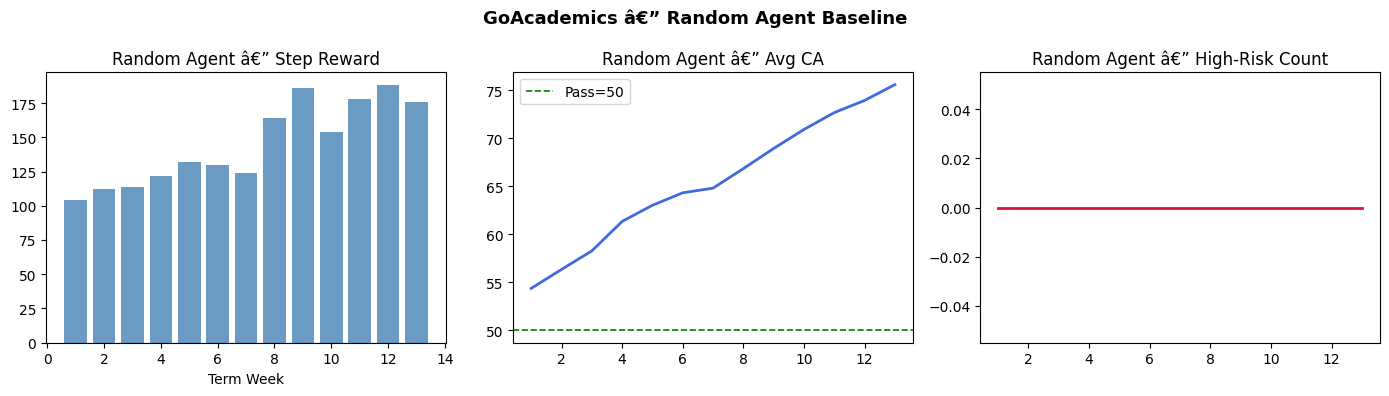

Random agent total reward: 1884.00


In [6]:
env = GoAcademicsEnv(n_students=N_STUDENTS, render_mode=None, seed=0)
obs, info = env.reset()

rewards_r, ca_r, att_r, risk_r = [], [], [], []
done = False
while not done:
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated
    rewards_r.append(reward)
    ca_r.append(info['avg_ca'])
    att_r.append(info['avg_attendance'])
    risk_r.append(info['risk_counts']['high'])
env.close()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
weeks = range(1, len(rewards_r)+1)

axes[0].bar(weeks, rewards_r, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Random Agent â€” Step Reward'); axes[0].set_xlabel('Term Week')

axes[1].plot(weeks, ca_r, color='royalblue', linewidth=2)
axes[1].axhline(50, color='green', linewidth=1.2, linestyle='--', label='Pass=50')
axes[1].set_title('Random Agent â€” Avg CA'); axes[1].legend()

axes[2].plot(weeks, risk_r, color='crimson', linewidth=2)
axes[2].set_title('Random Agent â€” High-Risk Count')

plt.suptitle('GoAcademics â€” Random Agent Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK}/models/random_agent_baseline.png', dpi=150)
plt.show()
print(f'Random agent total reward: {sum(rewards_r):.2f}')

## 5. DQN Training (10 Runs)

In [7]:
DQN_CONFIGS = [
    {'run':1,  'lr':1e-3,  'gamma':0.99, 'batch':64,  'buffer':10000, 'eps_s':1.0, 'eps_e':0.05, 'eps_f':0.1,  'tau':1.0,  'target_upd':500},
    {'run':2,  'lr':5e-4,  'gamma':0.99, 'batch':64,  'buffer':10000, 'eps_s':1.0, 'eps_e':0.05, 'eps_f':0.2,  'tau':1.0,  'target_upd':500},
    {'run':3,  'lr':1e-4,  'gamma':0.95, 'batch':32,  'buffer':5000,  'eps_s':1.0, 'eps_e':0.10, 'eps_f':0.1,  'tau':1.0,  'target_upd':250},
    {'run':4,  'lr':1e-3,  'gamma':0.90, 'batch':128, 'buffer':20000, 'eps_s':1.0, 'eps_e':0.01, 'eps_f':0.3,  'tau':1.0,  'target_upd':1000},
    {'run':5,  'lr':5e-4,  'gamma':0.95, 'batch':64,  'buffer':15000, 'eps_s':0.8, 'eps_e':0.05, 'eps_f':0.2,  'tau':0.5,  'target_upd':500},
    {'run':6,  'lr':2e-4,  'gamma':0.99, 'batch':256, 'buffer':50000, 'eps_s':1.0, 'eps_e':0.02, 'eps_f':0.5,  'tau':1.0,  'target_upd':2000},
    {'run':7,  'lr':1e-3,  'gamma':0.99, 'batch':64,  'buffer':10000, 'eps_s':1.0, 'eps_e':0.10, 'eps_f':0.1,  'tau':0.1,  'target_upd':500},
    {'run':8,  'lr':1e-4,  'gamma':0.99, 'batch':32,  'buffer':8000,  'eps_s':1.0, 'eps_e':0.05, 'eps_f':0.15, 'tau':1.0,  'target_upd':300},
    {'run':9,  'lr':3e-4,  'gamma':0.95, 'batch':128, 'buffer':30000, 'eps_s':1.0, 'eps_e':0.05, 'eps_f':0.25, 'tau':1.0,  'target_upd':750},
    {'run':10, 'lr':5e-3,  'gamma':0.90, 'batch':64,  'buffer':5000,  'eps_s':1.0, 'eps_e':0.20, 'eps_f':0.1,  'tau':1.0,  'target_upd':500},
]
DQN_NOTES = {
    1:'Baseline config. Stable convergence, moderate exploration.',
    2:'Lower LR. Slower but smoother learning curve.',
    3:'Low LR + smaller buffer. Slower convergence, higher variance.',
    4:'High batch + large buffer. More stable, lower exploration.',
    5:'Reduced initial eps + soft update. Faster exploitation onset.',
    6:'Very large buffer + long exploration. Best sample efficiency.',
    7:'Soft target update (tau=0.1). Smoother Q-value updates.',
    8:'Small batch + small buffer. Noisy but fast initial learning.',
    9:'Balanced mid-range config. Good generalization.',
    10:'High LR + high final eps. Unstable, overly exploratory.',
}

def make_single_env(seed=0):
    def _init(): return SingleStudentEnv(seed=seed)
    return _init

dqn_results = []

for cfg in DQN_CONFIGS:
    run_id   = cfg['run']
    save_dir = f'{DQN_DIR}/run_{run_id}'
    os.makedirs(save_dir, exist_ok=True)

    train_env = make_vec_env(make_single_env(seed=run_id), n_envs=4)
    eval_env  = make_vec_env(make_single_env(seed=run_id+100), n_envs=1)

    model = DQN(
        'MlpPolicy', train_env,
        learning_rate=cfg['lr'], gamma=cfg['gamma'],
        batch_size=cfg['batch'], buffer_size=cfg['buffer'],
        exploration_initial_eps=cfg['eps_s'], exploration_final_eps=cfg['eps_e'],
        exploration_fraction=cfg['eps_f'], tau=cfg['tau'],
        target_update_interval=cfg['target_upd'],
        verbose=0, seed=run_id,
    )
    eval_cb = EvalCallback(eval_env, best_model_save_path=save_dir,
                           log_path=save_dir, eval_freq=max(DQN_STEPS//20,1000),
                           n_eval_episodes=10, deterministic=True, render=False, verbose=0)

    print(f'DQN Run {run_id:>2} | lr={cfg["lr"]:.0e} | gamma={cfg["gamma"]} | '
          f'batch={cfg["batch"]} | buffer={cfg["buffer"]}', end=' ... ')

    t0 = time.time()
    model.learn(total_timesteps=DQN_STEPS, callback=eval_cb, progress_bar=False)
    elapsed = time.time() - t0

    model.save(f'{save_dir}/final_model')
    train_env.close()
    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
    eval_env.close()

    print(f'Mean reward: {mean_r:.2f} Â± {std_r:.2f}  ({elapsed:.0f}s)')
    dqn_results.append({
        'run':run_id, 'lr':cfg['lr'], 'gamma':cfg['gamma'], 'batch_size':cfg['batch'],
        'buffer_size':cfg['buffer'], 'exploration_initial_eps':cfg['eps_s'],
        'exploration_final_eps':cfg['eps_e'], 'exploration_fraction':cfg['eps_f'],
        'tau':cfg['tau'], 'target_update_interval':cfg['target_upd'],
        'mean_reward':round(mean_r,3), 'std_reward':round(std_r,3),
        'training_time_s':round(elapsed,1), 'behaviour_notes':DQN_NOTES[run_id],
    })

dqn_df = pd.DataFrame(dqn_results)
dqn_df.to_csv(f'{DQN_DIR}/dqn_results.csv', index=False)

best_dqn = max(dqn_results, key=lambda r: r['mean_reward'])
for f in os.listdir(f'{DQN_DIR}/run_{best_dqn["run"]}'):
    if 'model' in f: shutil.copy(f'{DQN_DIR}/run_{best_dqn["run"]}/{f}', f'{DQN_DIR}/best_model/')

print(f'\nBest DQN: Run #{best_dqn["run"]} | Mean reward: {best_dqn["mean_reward"]}')

DQN Run  1 | lr=1e-03 | gamma=0.99 | batch=64 | buffer=10000 ... Mean reward: 25.80 Â± 5.17  (27s)
DQN Run  2 | lr=5e-04 | gamma=0.99 | batch=64 | buffer=10000 ... Mean reward: 25.50 Â± 6.48  (25s)
DQN Run  3 | lr=1e-04 | gamma=0.95 | batch=32 | buffer=5000 ... Mean reward: 28.60 Â± 7.41  (26s)
DQN Run  4 | lr=1e-03 | gamma=0.9 | batch=128 | buffer=20000 ... Mean reward: 30.10 Â± 9.26  (26s)
DQN Run  5 | lr=5e-04 | gamma=0.95 | batch=64 | buffer=15000 ... Mean reward: 28.50 Â± 6.48  (26s)
DQN Run  6 | lr=2e-04 | gamma=0.99 | batch=256 | buffer=50000 ... Mean reward: 35.60 Â± 10.37  (25s)
DQN Run  7 | lr=1e-03 | gamma=0.99 | batch=64 | buffer=10000 ... Mean reward: 28.90 Â± 6.83  (26s)
DQN Run  8 | lr=1e-04 | gamma=0.99 | batch=32 | buffer=8000 ... Mean reward: 26.80 Â± 6.76  (26s)
DQN Run  9 | lr=3e-04 | gamma=0.95 | batch=128 | buffer=30000 ... Mean reward: 27.10 Â± 5.23  (25s)
DQN Run 10 | lr=5e-03 | gamma=0.9 | batch=64 | buffer=5000 ... Mean reward: 28.30 Â± 5.84  (25s)

Best DQN: 

In [8]:
display(dqn_df[['run','lr','gamma','batch_size','buffer_size','exploration_final_eps',
                'mean_reward','std_reward','training_time_s','behaviour_notes']]
        .sort_values('mean_reward', ascending=False).reset_index(drop=True)
        .style.background_gradient(subset=['mean_reward'], cmap='RdYlGn')
        .format({'lr':'{:.0e}','mean_reward':'{:.3f}','std_reward':'{:.3f}'}))

,run,lr,gamma,batch_size,buffer_size,exploration_final_eps,mean_reward,std_reward,training_time_s,behaviour_notes
0,6,2e-04,0.990000,256,50000,0.020000,35.600,10.365,24.900000,Very large buffer + long exploration. Best sample efficiency.
1,4,1e-03,0.900000,128,20000,0.010000,30.100,9.262,25.800000,"High batch + large buffer. More stable, lower exploration."
2,7,1e-03,0.990000,64,10000,0.100000,28.900,6.826,25.800000,Soft target update (tau=0.1). Smoother Q-value updates.
3,3,1e-04,0.950000,32,5000,0.100000,28.600,7.405,26.100000,"Low LR + smaller buffer. Slower convergence, higher variance."
4,5,5e-04,0.950000,64,15000,0.050000,28.500,6.477,25.800000,Reduced initial eps + soft update. Faster exploitation onset.
5,10,5e-03,0.900000,64,5000,0.200000,28.300,5.840,24.900000,"High LR + high final eps. Unstable, overly exploratory."
6,9,3e-04,0.950000,128,30000,0.050000,27.100,5.234,25.300000,Balanced mid-range config. Good generalization.
7,8,1e-04,0.990000,32,8000,0.050000,26.800,6.765,26.200000,Small batch + small buffer. Noisy but fast initial learning.
8,1,1e-03,0.990000,64,10000,0.050000,25.800,5.173,26.800000,"Baseline config. Stable convergence, moderate exploration."
9,2,5e-04,0.990000,64,10000,0.050000,25.500,6.477,25.500000,Lower LR. Slower but smoother learning curve.


## 6. REINFORCE Training (10 Runs)

In [9]:
REINFORCE_CONFIGS = [
    {'run':1,  'lr':1e-3, 'gamma':0.99, 'n_steps':13, 'ent_coef':0.01, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':2,  'lr':5e-4, 'gamma':0.99, 'n_steps':13, 'ent_coef':0.02, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':3,  'lr':1e-4, 'gamma':0.95, 'n_steps':13, 'ent_coef':0.01, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':4,  'lr':3e-3, 'gamma':0.99, 'n_steps':13, 'ent_coef':0.00, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':5,  'lr':1e-3, 'gamma':0.90, 'n_steps':13, 'ent_coef':0.05, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':6,  'lr':2e-4, 'gamma':0.99, 'n_steps':26, 'ent_coef':0.01, 'vf_coef':0.0, 'max_grad':1.0},
    {'run':7,  'lr':1e-3, 'gamma':0.99, 'n_steps':13, 'ent_coef':0.01, 'vf_coef':0.0, 'max_grad':0.1},
    {'run':8,  'lr':5e-4, 'gamma':0.95, 'n_steps':13, 'ent_coef':0.10, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':9,  'lr':1e-3, 'gamma':0.99, 'n_steps':52, 'ent_coef':0.01, 'vf_coef':0.0, 'max_grad':0.5},
    {'run':10, 'lr':5e-3, 'gamma':0.90, 'n_steps':13, 'ent_coef':0.00, 'vf_coef':0.0, 'max_grad':2.0},
]
REINFORCE_NOTES = {
    1:'Baseline REINFORCE. Stable but high variance due to no baseline.',
    2:'Lower LR. Slower convergence, reduced variance.',
    3:'Low LR + lower gamma. Weak long-term credit assignment.',
    4:'High LR + zero entropy. Fast but greedy policy collapse risk.',
    5:'High entropy coefficient. Strong exploration, slow exploitation.',
    6:'Doubled n_steps. More complete returns, lower bias.',
    7:'Very low max_grad. Prevents large policy updates.',
    8:'High entropy + lower gamma. Exploratory, moderate performance.',
    9:'Very long rollouts (4 episodes). Reduces variance further.',
    10:'High LR + zero entropy. Likely unstable and divergent.',
}

def make_classroom_env(seed=0, n_students=N_STUDENTS):
    def _init(): return GoAcademicsEnv(n_students=n_students, render_mode=None, seed=seed)
    return _init

reinforce_results = []
rf_dir = f'{PG_DIR}/reinforce'

for cfg in REINFORCE_CONFIGS:
    run_id   = cfg['run']
    save_dir = f'{rf_dir}/run_{run_id}'
    os.makedirs(save_dir, exist_ok=True)

    train_env = make_vec_env(make_classroom_env(seed=run_id), n_envs=4)
    eval_env  = make_vec_env(make_classroom_env(seed=run_id+200), n_envs=1)

    model = A2C('MlpPolicy', train_env, learning_rate=cfg['lr'], gamma=cfg['gamma'],
                n_steps=cfg['n_steps'], ent_coef=cfg['ent_coef'], vf_coef=cfg['vf_coef'],
                max_grad_norm=cfg['max_grad'], verbose=0, seed=run_id)
    eval_cb = EvalCallback(eval_env, best_model_save_path=save_dir, log_path=save_dir,
                           eval_freq=max(PG_STEPS//20,2000), n_eval_episodes=10,
                           deterministic=True, render=False, verbose=0)

    print(f'REINFORCE Run {run_id:>2} | lr={cfg["lr"]:.0e} | n_steps={cfg["n_steps"]} | ent={cfg["ent_coef"]}', end=' ... ')
    t0 = time.time()
    model.learn(total_timesteps=PG_STEPS, callback=eval_cb, progress_bar=False)
    elapsed = time.time() - t0
    model.save(f'{save_dir}/final_model')
    train_env.close()
    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
    eval_env.close()
    print(f'Mean reward: {mean_r:.2f} Â± {std_r:.2f}  ({elapsed:.0f}s)')
    reinforce_results.append({
        'run':run_id,'lr':cfg['lr'],'gamma':cfg['gamma'],'n_steps':cfg['n_steps'],
        'ent_coef':cfg['ent_coef'],'vf_coef':cfg['vf_coef'],'max_grad_norm':cfg['max_grad'],
        'mean_reward':round(mean_r,3),'std_reward':round(std_r,3),
        'training_time_s':round(elapsed,1),'behaviour_notes':REINFORCE_NOTES[run_id],
    })

rf_df = pd.DataFrame(reinforce_results)
rf_df.to_csv(f'{rf_dir}/reinforce_results.csv', index=False)
print(f'Best REINFORCE: Run #{max(reinforce_results, key=lambda r: r["mean_reward"])["run"]}')

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


REINFORCE Run  1 | lr=1e-03 | n_steps=13 | ent=0.01 ... Mean reward: 1718.70 Â± 317.34  (319s)
REINFORCE Run  2 | lr=5e-04 | n_steps=13 | ent=0.02 ... Mean reward: 1765.20 Â± 312.56  (320s)
REINFORCE Run  3 | lr=1e-04 | n_steps=13 | ent=0.01 ... Mean reward: 1563.90 Â± 305.74  (321s)
REINFORCE Run  4 | lr=3e-03 | n_steps=13 | ent=0.0 ... Mean reward: 1363.80 Â± 362.19  (321s)
REINFORCE Run  5 | lr=1e-03 | n_steps=13 | ent=0.05 ... Mean reward: 1853.20 Â± 324.78  (324s)
REINFORCE Run  6 | lr=2e-04 | n_steps=26 | ent=0.01 ... Mean reward: 1866.70 Â± 360.01  (304s)
REINFORCE Run  7 | lr=1e-03 | n_steps=13 | ent=0.01 ... Mean reward: 1392.25 Â± 433.85  (318s)
REINFORCE Run  8 | lr=5e-04 | n_steps=13 | ent=0.1 ... Mean reward: 1683.60 Â± 316.81  (322s)
REINFORCE Run  9 | lr=1e-03 | n_steps=52 | ent=0.01 ... Mean reward: 1842.75 Â± 258.53  (295s)
REINFORCE Run 10 | lr=5e-03 | n_steps=13 | ent=0.0 ... Mean reward: 1522.90 Â± 337.20  (318s)
Best REINFORCE: Run #6


In [10]:
display(rf_df[['run','lr','gamma','n_steps','ent_coef','mean_reward','std_reward','behaviour_notes']]
        .sort_values('mean_reward', ascending=False).reset_index(drop=True)
        .style.background_gradient(subset=['mean_reward'], cmap='RdYlGn')
        .format({'lr':'{:.0e}','mean_reward':'{:.3f}','std_reward':'{:.3f}'}))

,run,lr,gamma,n_steps,ent_coef,mean_reward,std_reward,behaviour_notes
0,6,2e-04,0.990000,26,0.010000,1866.700,360.011,"Doubled n_steps. More complete returns, lower bias."
1,5,1e-03,0.900000,13,0.050000,1853.200,324.779,"High entropy coefficient. Strong exploration, slow exploitation."
2,9,1e-03,0.990000,52,0.010000,1842.750,258.534,Very long rollouts (4 episodes). Reduces variance further.
3,2,5e-04,0.990000,13,0.020000,1765.200,312.556,"Lower LR. Slower convergence, reduced variance."
4,1,1e-03,0.990000,13,0.010000,1718.700,317.342,Baseline REINFORCE. Stable but high variance due to no baseline.
5,8,5e-04,0.950000,13,0.100000,1683.600,316.812,"High entropy + lower gamma. Exploratory, moderate performance."
6,3,1e-04,0.950000,13,0.010000,1563.900,305.735,Low LR + lower gamma. Weak long-term credit assignment.
7,10,5e-03,0.900000,13,0.000000,1522.900,337.201,High LR + zero entropy. Likely unstable and divergent.
8,7,1e-03,0.990000,13,0.010000,1392.250,433.854,Very low max_grad. Prevents large policy updates.
9,4,3e-03,0.990000,13,0.000000,1363.800,362.191,High LR + zero entropy. Fast but greedy policy collapse risk.


## 7. PPO Training (10 Runs)

In [11]:
PPO_CONFIGS = [
    {'run':1,  'lr':3e-4,'gamma':0.99,'n_steps':256, 'batch':64, 'n_epochs':10,'clip':0.2, 'ent_coef':0.01,'vf_coef':0.5,'max_grad':0.5},
    {'run':2,  'lr':1e-4,'gamma':0.99,'n_steps':512, 'batch':64, 'n_epochs':10,'clip':0.2, 'ent_coef':0.01,'vf_coef':0.5,'max_grad':0.5},
    {'run':3,  'lr':5e-4,'gamma':0.95,'n_steps':256, 'batch':128,'n_epochs':5, 'clip':0.2, 'ent_coef':0.00,'vf_coef':0.5,'max_grad':0.5},
    {'run':4,  'lr':3e-4,'gamma':0.99,'n_steps':128, 'batch':32, 'n_epochs':20,'clip':0.1, 'ent_coef':0.01,'vf_coef':0.5,'max_grad':0.5},
    {'run':5,  'lr':3e-4,'gamma':0.99,'n_steps':256, 'batch':64, 'n_epochs':10,'clip':0.3, 'ent_coef':0.02,'vf_coef':0.5,'max_grad':0.5},
    {'run':6,  'lr':1e-3,'gamma':0.99,'n_steps':1024,'batch':256,'n_epochs':5, 'clip':0.2, 'ent_coef':0.01,'vf_coef':0.5,'max_grad':0.5},
    {'run':7,  'lr':3e-4,'gamma':0.90,'n_steps':256, 'batch':64, 'n_epochs':10,'clip':0.2, 'ent_coef':0.01,'vf_coef':1.0,'max_grad':0.5},
    {'run':8,  'lr':2e-4,'gamma':0.99,'n_steps':512, 'batch':128,'n_epochs':15,'clip':0.15,'ent_coef':0.05,'vf_coef':0.5,'max_grad':1.0},
    {'run':9,  'lr':3e-4,'gamma':0.99,'n_steps':256, 'batch':64, 'n_epochs':10,'clip':0.2, 'ent_coef':0.01,'vf_coef':0.5,'max_grad':0.5},
    {'run':10, 'lr':5e-3,'gamma':0.90,'n_steps':64,  'batch':32, 'n_epochs':3, 'clip':0.4, 'ent_coef':0.10,'vf_coef':0.1,'max_grad':2.0},
]
PPO_NOTES = {
    1:'Standard PPO baseline. Reliable convergence.',
    2:'Lower LR + larger rollouts. More stable value estimates.',
    3:'Higher LR + zero entropy. Deterministic policy faster.',
    4:'More epochs + tighter clip. Conservative policy updates.',
    5:'Wider clip range. Allows larger updates, may destabilise.',
    6:'Large batch + high LR. Sample-efficient but noisy.',
    7:'High vf_coef + lower gamma. Prioritises value accuracy.',
    8:'High entropy + tight clip. Balances explore/exploit well.',
    9:'Same as run 1 with different seed. Reproducibility check.',
    10:'Aggressive settings. High variance, likely sub-optimal.',
}

ppo_results = []
ppo_dir = f'{PG_DIR}/ppo'

for cfg in PPO_CONFIGS:
    run_id   = cfg['run']
    save_dir = f'{ppo_dir}/run_{run_id}'
    os.makedirs(save_dir, exist_ok=True)

    train_env = make_vec_env(make_classroom_env(seed=run_id), n_envs=4)
    eval_env  = make_vec_env(make_classroom_env(seed=run_id+300), n_envs=1)

    model = PPO('MlpPolicy', train_env, learning_rate=cfg['lr'], gamma=cfg['gamma'],
                n_steps=cfg['n_steps'], batch_size=cfg['batch'], n_epochs=cfg['n_epochs'],
                clip_range=cfg['clip'], ent_coef=cfg['ent_coef'], vf_coef=cfg['vf_coef'],
                max_grad_norm=cfg['max_grad'], verbose=0, seed=run_id)
    eval_cb = EvalCallback(eval_env, best_model_save_path=save_dir, log_path=save_dir,
                           eval_freq=max(PG_STEPS//20,2000), n_eval_episodes=10,
                           deterministic=True, render=False, verbose=0)

    print(f'PPO Run {run_id:>2} | lr={cfg["lr"]:.0e} | clip={cfg["clip"]} | n_epochs={cfg["n_epochs"]}', end=' ... ')
    t0 = time.time()
    model.learn(total_timesteps=PG_STEPS, callback=eval_cb, progress_bar=False)
    elapsed = time.time() - t0
    model.save(f'{save_dir}/final_model')
    train_env.close()
    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
    eval_env.close()
    print(f'Mean reward: {mean_r:.2f} Â± {std_r:.2f}  ({elapsed:.0f}s)')
    ppo_results.append({
        'run':run_id,'lr':cfg['lr'],'gamma':cfg['gamma'],'n_steps':cfg['n_steps'],
        'batch_size':cfg['batch'],'n_epochs':cfg['n_epochs'],'clip_range':cfg['clip'],
        'ent_coef':cfg['ent_coef'],'vf_coef':cfg['vf_coef'],'max_grad_norm':cfg['max_grad'],
        'mean_reward':round(mean_r,3),'std_reward':round(std_r,3),
        'training_time_s':round(elapsed,1),'behaviour_notes':PPO_NOTES[run_id],
    })

ppo_df = pd.DataFrame(ppo_results)
ppo_df.to_csv(f'{ppo_dir}/ppo_results.csv', index=False)
print(f'Best PPO: Run #{max(ppo_results, key=lambda r: r["mean_reward"])["run"]}')

PPO Run  1 | lr=3e-04 | clip=0.2 | n_epochs=10 ... 

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Mean reward: 1587.20 Â± 366.52  (548s)
PPO Run  2 | lr=1e-04 | clip=0.2 | n_epochs=10 ... Mean reward: 1873.00 Â± 300.35  (551s)
PPO Run  3 | lr=5e-04 | clip=0.2 | n_epochs=5 ... Mean reward: 1886.40 Â± 241.69  (353s)
PPO Run  4 | lr=3e-04 | clip=0.1 | n_epochs=20 ... Mean reward: 1829.80 Â± 307.55  (1332s)
PPO Run  5 | lr=3e-04 | clip=0.3 | n_epochs=10 ... Mean reward: 1633.70 Â± 337.95  (549s)
PPO Run  6 | lr=1e-03 | clip=0.2 | n_epochs=5 ... Mean reward: 1635.30 Â± 480.49  (325s)
PPO Run  7 | lr=3e-04 | clip=0.2 | n_epochs=10 ... Mean reward: 1812.55 Â± 334.73  (549s)
PPO Run  8 | lr=2e-04 | clip=0.15 | n_epochs=15 ... Mean reward: 1823.85 Â± 291.93  (489s)
PPO Run  9 | lr=3e-04 | clip=0.2 | n_epochs=10 ... Mean reward: 1754.00 Â± 308.56  (547s)
PPO Run 10 | lr=5e-03 | clip=0.4 | n_epochs=3 ... Mean reward: 1393.45 Â± 328.72  (442s)
Best PPO: Run #3


In [12]:
display(ppo_df[['run','lr','gamma','n_steps','batch_size','clip_range','ent_coef','mean_reward','std_reward','behaviour_notes']]
        .sort_values('mean_reward', ascending=False).reset_index(drop=True)
        .style.background_gradient(subset=['mean_reward'], cmap='RdYlGn')
        .format({'lr':'{:.0e}','mean_reward':'{:.3f}','std_reward':'{:.3f}'}))

,run,lr,gamma,n_steps,batch_size,clip_range,ent_coef,mean_reward,std_reward,behaviour_notes
0,3,5e-04,0.950000,256,128,0.200000,0.000000,1886.400,241.690,Higher LR + zero entropy. Deterministic policy faster.
1,2,1e-04,0.990000,512,64,0.200000,0.010000,1873.000,300.348,Lower LR + larger rollouts. More stable value estimates.
2,4,3e-04,0.990000,128,32,0.100000,0.010000,1829.800,307.547,More epochs + tighter clip. Conservative policy updates.
3,8,2e-04,0.990000,512,128,0.150000,0.050000,1823.850,291.926,High entropy + tight clip. Balances explore/exploit well.
4,7,3e-04,0.900000,256,64,0.200000,0.010000,1812.550,334.735,High vf_coef + lower gamma. Prioritises value accuracy.
5,9,3e-04,0.990000,256,64,0.200000,0.010000,1754.000,308.564,Same as run 1 with different seed. Reproducibility check.
6,6,1e-03,0.990000,1024,256,0.200000,0.010000,1635.300,480.491,Large batch + high LR. Sample-efficient but noisy.
7,5,3e-04,0.990000,256,64,0.300000,0.020000,1633.700,337.946,"Wider clip range. Allows larger updates, may destabilise."
8,1,3e-04,0.990000,256,64,0.200000,0.010000,1587.200,366.525,Standard PPO baseline. Reliable convergence.
9,10,5e-03,0.900000,64,32,0.400000,0.100000,1393.450,328.719,"Aggressive settings. High variance, likely sub-optimal."


## 8. A2C Training (10 Runs)

In [13]:
A2C_CONFIGS = [
    {'run':1,  'lr':7e-4,'gamma':0.99,'n_steps':5,  'ent_coef':0.01,'vf_coef':0.5, 'max_grad':0.5},
    {'run':2,  'lr':1e-3,'gamma':0.99,'n_steps':5,  'ent_coef':0.01,'vf_coef':0.5, 'max_grad':0.5},
    {'run':3,  'lr':5e-4,'gamma':0.95,'n_steps':10, 'ent_coef':0.01,'vf_coef':0.5, 'max_grad':0.5},
    {'run':4,  'lr':7e-4,'gamma':0.99,'n_steps':5,  'ent_coef':0.05,'vf_coef':0.5, 'max_grad':0.5},
    {'run':5,  'lr':7e-4,'gamma':0.99,'n_steps':5,  'ent_coef':0.00,'vf_coef':0.5, 'max_grad':0.5},
    {'run':6,  'lr':2e-4,'gamma':0.99,'n_steps':20, 'ent_coef':0.01,'vf_coef':0.5, 'max_grad':1.0},
    {'run':7,  'lr':7e-4,'gamma':0.99,'n_steps':5,  'ent_coef':0.01,'vf_coef':1.0, 'max_grad':0.5},
    {'run':8,  'lr':1e-3,'gamma':0.90,'n_steps':5,  'ent_coef':0.01,'vf_coef':0.25,'max_grad':0.5},
    {'run':9,  'lr':3e-4,'gamma':0.99,'n_steps':13, 'ent_coef':0.02,'vf_coef':0.5, 'max_grad':0.5},
    {'run':10, 'lr':5e-3,'gamma':0.90,'n_steps':5,  'ent_coef':0.10,'vf_coef':0.1, 'max_grad':2.0},
]
A2C_NOTES = {
    1:'Baseline A2C. Steady convergence, low variance.',
    2:'Higher LR. Faster but slightly noisier learning.',
    3:'Longer n_steps. Reduces bias in advantage estimates.',
    4:'High entropy. More exploration, slower exploitation.',
    5:'Zero entropy. Deterministic, risk of premature convergence.',
    6:'Very long n_steps (20). Low-bias returns, high variance.',
    7:'High vf_coef. Stronger value function signal.',
    8:'Lower gamma + reduced vf_coef. Less future credit.',
    9:'Episode-length n_steps (13). Full-episode advantages.',
    10:'Aggressive LR + entropy. Likely unstable.',
}

a2c_results = []
a2c_dir = f'{PG_DIR}/a2c'

for cfg in A2C_CONFIGS:
    run_id   = cfg['run']
    save_dir = f'{a2c_dir}/run_{run_id}'
    os.makedirs(save_dir, exist_ok=True)

    train_env = make_vec_env(make_classroom_env(seed=run_id), n_envs=4)
    eval_env  = make_vec_env(make_classroom_env(seed=run_id+400), n_envs=1)

    model = A2C('MlpPolicy', train_env, learning_rate=cfg['lr'], gamma=cfg['gamma'],
                n_steps=cfg['n_steps'], ent_coef=cfg['ent_coef'], vf_coef=cfg['vf_coef'],
                max_grad_norm=cfg['max_grad'], verbose=0, seed=run_id)
    eval_cb = EvalCallback(eval_env, best_model_save_path=save_dir, log_path=save_dir,
                           eval_freq=max(PG_STEPS//20,2000), n_eval_episodes=10,
                           deterministic=True, render=False, verbose=0)

    print(f'A2C Run {run_id:>2} | lr={cfg["lr"]:.0e} | n_steps={cfg["n_steps"]} | vf={cfg["vf_coef"]}', end=' ... ')
    t0 = time.time()
    model.learn(total_timesteps=PG_STEPS, callback=eval_cb, progress_bar=False)
    elapsed = time.time() - t0
    model.save(f'{save_dir}/final_model')
    train_env.close()
    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
    eval_env.close()
    print(f'Mean reward: {mean_r:.2f} Â± {std_r:.2f}  ({elapsed:.0f}s)')
    a2c_results.append({
        'run':run_id,'lr':cfg['lr'],'gamma':cfg['gamma'],'n_steps':cfg['n_steps'],
        'ent_coef':cfg['ent_coef'],'vf_coef':cfg['vf_coef'],'max_grad_norm':cfg['max_grad'],
        'mean_reward':round(mean_r,3),'std_reward':round(std_r,3),
        'training_time_s':round(elapsed,1),'behaviour_notes':A2C_NOTES[run_id],
    })

a2c_df = pd.DataFrame(a2c_results)
a2c_df.to_csv(f'{a2c_dir}/a2c_results.csv', index=False)
print(f'Best A2C: Run #{max(a2c_results, key=lambda r: r["mean_reward"])["run"]}')

A2C Run  1 | lr=7e-04 | n_steps=5 | vf=0.5 ... 

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Mean reward: 1720.95 Â± 336.07  (376s)
A2C Run  2 | lr=1e-03 | n_steps=5 | vf=0.5 ... Mean reward: 1895.10 Â± 304.87  (380s)
A2C Run  3 | lr=5e-04 | n_steps=10 | vf=0.5 ... Mean reward: 1855.15 Â± 308.61  (335s)
A2C Run  4 | lr=7e-04 | n_steps=5 | vf=0.5 ... Mean reward: 1916.00 Â± 399.17  (377s)
A2C Run  5 | lr=7e-04 | n_steps=5 | vf=0.5 ... Mean reward: 1795.00 Â± 276.51  (377s)
A2C Run  6 | lr=2e-04 | n_steps=20 | vf=0.5 ... Mean reward: 1803.80 Â± 349.02  (312s)
A2C Run  7 | lr=7e-04 | n_steps=5 | vf=1.0 ... Mean reward: 1875.30 Â± 304.32  (375s)
A2C Run  8 | lr=1e-03 | n_steps=5 | vf=0.25 ... Mean reward: 1881.20 Â± 258.31  (380s)
A2C Run  9 | lr=3e-04 | n_steps=13 | vf=0.5 ... Mean reward: 1847.20 Â± 323.42  (327s)
A2C Run 10 | lr=5e-03 | n_steps=5 | vf=0.1 ... Mean reward: 1335.75 Â± 327.63  (373s)
Best A2C: Run #4


In [14]:
display(a2c_df[['run','lr','gamma','n_steps','ent_coef','vf_coef','mean_reward','std_reward','behaviour_notes']]
        .sort_values('mean_reward', ascending=False).reset_index(drop=True)
        .style.background_gradient(subset=['mean_reward'], cmap='RdYlGn')
        .format({'lr':'{:.0e}','mean_reward':'{:.3f}','std_reward':'{:.3f}'}))

,run,lr,gamma,n_steps,ent_coef,vf_coef,mean_reward,std_reward,behaviour_notes
0,4,7e-04,0.990000,5,0.050000,0.500000,1916.000,399.168,"High entropy. More exploration, slower exploitation."
1,2,1e-03,0.990000,5,0.010000,0.500000,1895.100,304.870,Higher LR. Faster but slightly noisier learning.
2,8,1e-03,0.900000,5,0.010000,0.250000,1881.200,258.309,Lower gamma + reduced vf_coef. Less future credit.
3,7,7e-04,0.990000,5,0.010000,1.000000,1875.300,304.324,High vf_coef. Stronger value function signal.
4,3,5e-04,0.950000,10,0.010000,0.500000,1855.150,308.605,Longer n_steps. Reduces bias in advantage estimates.
5,9,3e-04,0.990000,13,0.020000,0.500000,1847.200,323.424,Episode-length n_steps (13). Full-episode advantages.
6,6,2e-04,0.990000,20,0.010000,0.500000,1803.800,349.020,"Very long n_steps (20). Low-bias returns, high variance."
7,5,7e-04,0.990000,5,0.000000,0.500000,1795.000,276.512,"Zero entropy. Deterministic, risk of premature convergence."
8,1,7e-04,0.990000,5,0.010000,0.500000,1720.950,336.074,"Baseline A2C. Steady convergence, low variance."
9,10,5e-03,0.900000,5,0.100000,0.100000,1335.750,327.631,Aggressive LR + entropy. Likely unstable.


## 9. Results Analysis & Plots

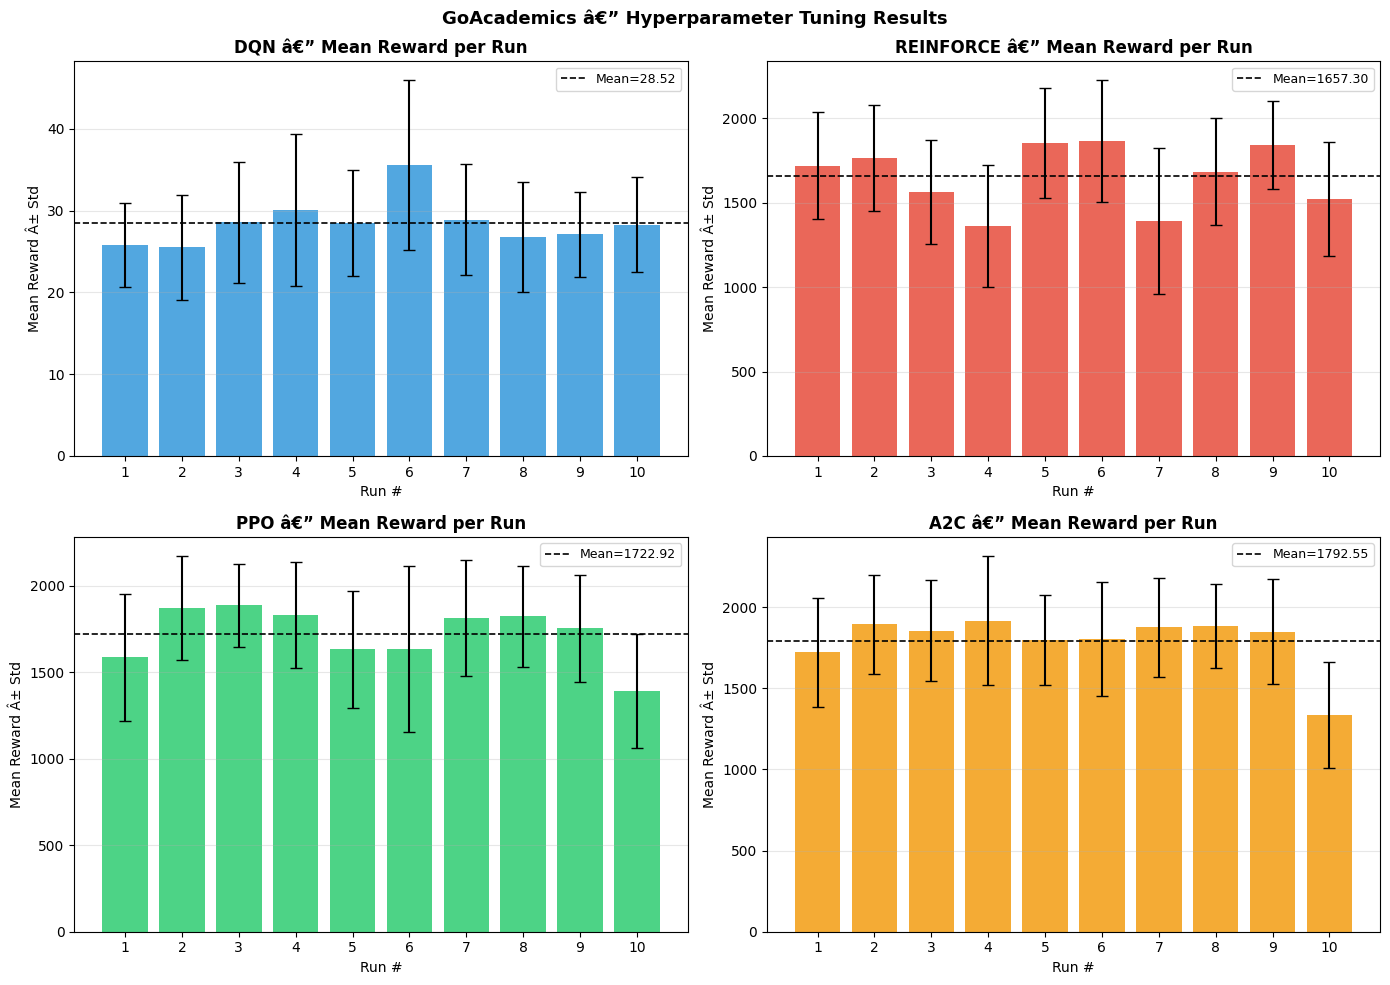

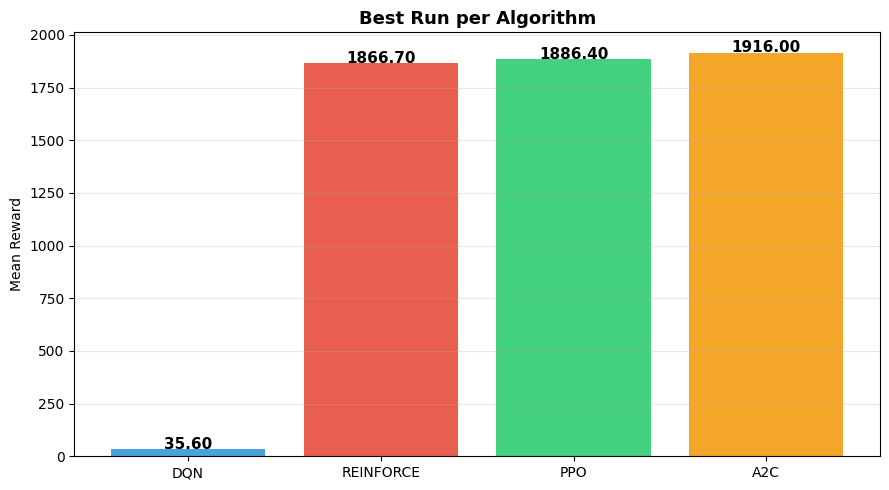

Plots saved to /kaggle/working/models/


In [15]:
colours = {'DQN':'#3498db','REINFORCE':'#e74c3c','PPO':'#2ecc71','A2C':'#f39c12'}
summary = {
    'DQN':       (dqn_df['mean_reward'].values, dqn_df['std_reward'].values),
    'REINFORCE': (rf_df['mean_reward'].values,  rf_df['std_reward'].values),
    'PPO':       (ppo_df['mean_reward'].values,  ppo_df['std_reward'].values),
    'A2C':       (a2c_df['mean_reward'].values,  a2c_df['std_reward'].values),
}

# â”€â”€ per-algorithm bar charts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (algo, (means, stds)) in zip(axes.flatten(), summary.items()):
    runs = np.arange(1, len(means)+1)
    ax.bar(runs, means, yerr=stds, capsize=4, color=colours[algo], alpha=0.85)
    ax.axhline(np.mean(means), color='black', linewidth=1.2, linestyle='--',
               label=f'Mean={np.mean(means):.2f}')
    ax.set_title(f'{algo} â€” Mean Reward per Run', fontweight='bold')
    ax.set_xlabel('Run #'); ax.set_ylabel('Mean Reward Â± Std')
    ax.set_xticks(runs); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.suptitle('GoAcademics â€” Hyperparameter Tuning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK}/models/all_algorithms_comparison.png', dpi=150)
plt.show()

# â”€â”€ best-run bar chart â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
best_means = [dqn_df['mean_reward'].max(), rf_df['mean_reward'].max(),
              ppo_df['mean_reward'].max(), a2c_df['mean_reward'].max()]
algo_names = ['DQN','REINFORCE','PPO','A2C']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(algo_names, best_means, color=[colours[a] for a in algo_names], alpha=0.9)
for bar, val in zip(bars, best_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Best Run per Algorithm', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean Reward'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK}/models/best_run_comparison.png', dpi=150)
plt.show()
print('Plots saved to /kaggle/working/models/')

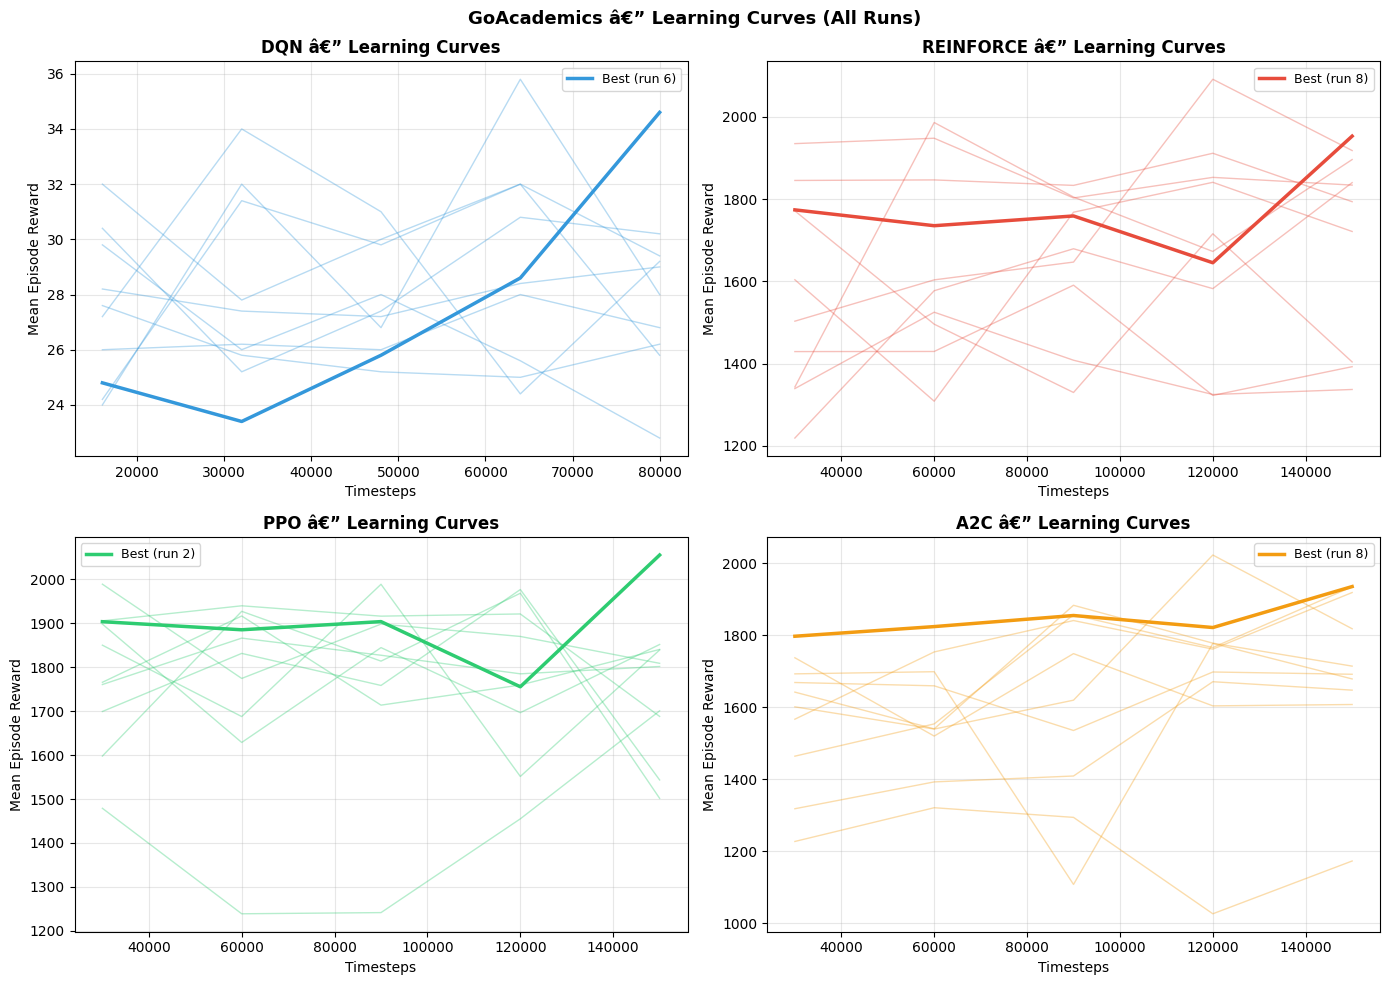

Saved â†’ /kaggle/working/models/learning_curves.png


In [16]:
# â”€â”€ Learning curves from EvalCallback logs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def load_eval_log(path):
    npz = os.path.join(path, 'evaluations.npz')
    if not os.path.exists(npz): return None, None
    data = np.load(npz)
    return data['timesteps'], data['results'].mean(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
specs = [
    ('DQN',       DQN_DIR,          DQN_CONFIGS,        colours['DQN']),
    ('REINFORCE', f'{PG_DIR}/reinforce', REINFORCE_CONFIGS, colours['REINFORCE']),
    ('PPO',       f'{PG_DIR}/ppo',       PPO_CONFIGS,        colours['PPO']),
    ('A2C',       f'{PG_DIR}/a2c',       A2C_CONFIGS,        colours['A2C']),
]

for ax, (algo, algo_dir, cfgs, col) in zip(axes.flatten(), specs):
    best_run_id, best_final = None, -np.inf
    for cfg in cfgs:
        ts, means = load_eval_log(f'{algo_dir}/run_{cfg["run"]}')
        if ts is None: continue
        ax.plot(ts, means, alpha=0.35, linewidth=1, color=col)
        if means[-1] > best_final:
            best_final, best_run_id = means[-1], cfg['run']
            bts, bm = ts, means
    if best_run_id:
        ax.plot(bts, bm, linewidth=2.5, color=col, label=f'Best (run {best_run_id})', zorder=5)
    ax.set_title(f'{algo} â€” Learning Curves', fontweight='bold')
    ax.set_xlabel('Timesteps'); ax.set_ylabel('Mean Episode Reward')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('GoAcademics â€” Learning Curves (All Runs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK}/models/learning_curves.png', dpi=150)
plt.show()
print('Saved â†’ /kaggle/working/models/learning_curves.png')

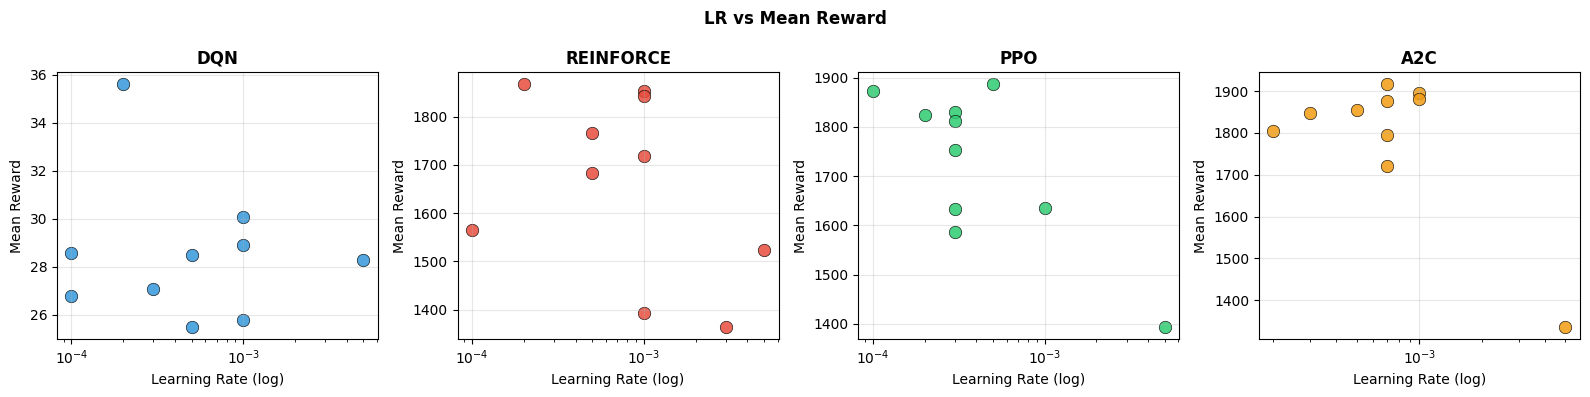


  Best DQN      : Run #6 | 35.600
  Best REINFORCE: Run #6 | 1866.700
  Best PPO      : Run #3 | 1886.400
  Best A2C      : Run #4 | 1916.000
  Overall best PG: A2C run #4 (1916.000)


In [17]:
# â”€â”€ LR sensitivity â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (algo, df, col) in zip(axes, [('DQN',dqn_df,colours['DQN']),
                                       ('REINFORCE',rf_df,colours['REINFORCE']),
                                       ('PPO',ppo_df,colours['PPO']),
                                       ('A2C',a2c_df,colours['A2C'])]):
    ax.scatter(df['lr'], df['mean_reward'], color=col, s=80, alpha=0.85, edgecolors='black', linewidth=0.5)
    ax.set_xscale('log'); ax.set_title(algo, fontweight='bold')
    ax.set_xlabel('Learning Rate (log)'); ax.set_ylabel('Mean Reward'); ax.grid(alpha=0.3)
plt.suptitle('LR vs Mean Reward', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK}/models/lr_sensitivity.png', dpi=150)
plt.show()

# â”€â”€ save best PG metadata â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
all_pg = [('reinforce',reinforce_results),('ppo',ppo_results),('a2c',a2c_results)]
best_pg_algo, best_pg_run, best_pg_reward = None, None, -np.inf
for aname, res in all_pg:
    for r in res:
        if r['mean_reward'] > best_pg_reward:
            best_pg_reward, best_pg_algo, best_pg_run = r['mean_reward'], aname, r['run']

src = f'{PG_DIR}/{best_pg_algo}/run_{best_pg_run}'
for f in os.listdir(src):
    if 'model' in f: shutil.copy(f'{src}/{f}', f'{PG_DIR}/best_model/')
with open(f'{PG_DIR}/best_model/metadata.txt','w') as f:
    f.write(f'algorithm={best_pg_algo}\nrun={best_pg_run}\nmean_reward={best_pg_reward:.3f}\n')

print('\n' + '='*55)
print(f'  Best DQN      : Run #{best_dqn["run"]} | {best_dqn["mean_reward"]:.3f}')
print(f'  Best REINFORCE: Run #{max(reinforce_results,key=lambda r:r["mean_reward"])["run"]} | {rf_df["mean_reward"].max():.3f}')
print(f'  Best PPO      : Run #{max(ppo_results,key=lambda r:r["mean_reward"])["run"]} | {ppo_df["mean_reward"].max():.3f}')
print(f'  Best A2C      : Run #{max(a2c_results,key=lambda r:r["mean_reward"])["run"]} | {a2c_df["mean_reward"].max():.3f}')
print(f'  Overall best PG: {best_pg_algo.upper()} run #{best_pg_run} ({best_pg_reward:.3f})')
print('='*55)

## 10. Run Best Agent

In [18]:
best_model_path = f'{PG_DIR}/best_model/final_model'
if not os.path.exists(best_model_path + '.zip'):
    best_model_path = f'{PG_DIR}/best_model/best_model'

best_model = (PPO if best_pg_algo == 'ppo' else A2C).load(best_model_path)

env = GoAcademicsEnv(n_students=N_STUDENTS, render_mode=None, seed=99)
obs, info = env.reset()
done, ep_reward, weekly_log = False, 0.0, []

print(f'Running best {best_pg_algo.upper()} agent (run #{best_pg_run})...')
print(f'{"Week":>5} {"Reward":>8} {"Passed":>7} {"Dropped":>8} {"HighRisk":>9} {"AvgCA":>7} {"AvgAtt":>8}')
print('-'*60)

while not done:
    action, _ = best_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    ep_reward += reward
    done = terminated or truncated
    weekly_log.append({'week':info['term_week'], 'reward':reward,
                       'passed':info['n_passed'], 'dropped':info['n_dropped'],
                       'high_risk':info['risk_counts']['high'],
                       'avg_ca':info['avg_ca'], 'avg_att':info['avg_attendance']})
    print(f"{info['term_week']:>5} {reward:>+8.1f} {info['n_passed']:>7} "
          f"{info['n_dropped']:>8} {info['risk_counts']['high']:>9} "
          f"{info['avg_ca']:>7.1f} {info['avg_attendance']:>7.1%}")

env.close()
print(f'\nTotal reward: {ep_reward:.2f} | Pass rate: {weekly_log[-1]["passed"]}/{N_STUDENTS}')

Running best A2C agent (run #4)...
 Week   Reward  Passed  Dropped  HighRisk   AvgCA   AvgAtt
------------------------------------------------------------
    2   +122.0       5        0         0    54.4   82.6%
    3   +112.0       5        0         0    57.4   84.2%
    4   +122.0       5        0         0    60.3   85.9%
    5   +124.0       5        0         0    62.9   87.7%
    6   +116.0       5        0         0    65.6   89.2%
    7   +146.0       6        0         0    68.6   89.9%
    8   +158.0       7        0         0    71.5   90.4%
    9   +158.0       7        0         0    73.9   91.1%
   10   +178.0       8        0         0    76.1   92.0%
   11   +178.0       8        0         0    78.3   92.5%
   12   +178.0       8        0         0    80.5   93.0%
   13   +178.0       8        0         0    82.5   93.4%
   14   +178.0       8        0         0    84.4   93.8%

Total reward: 1948.00 | Pass rate: 8/10


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


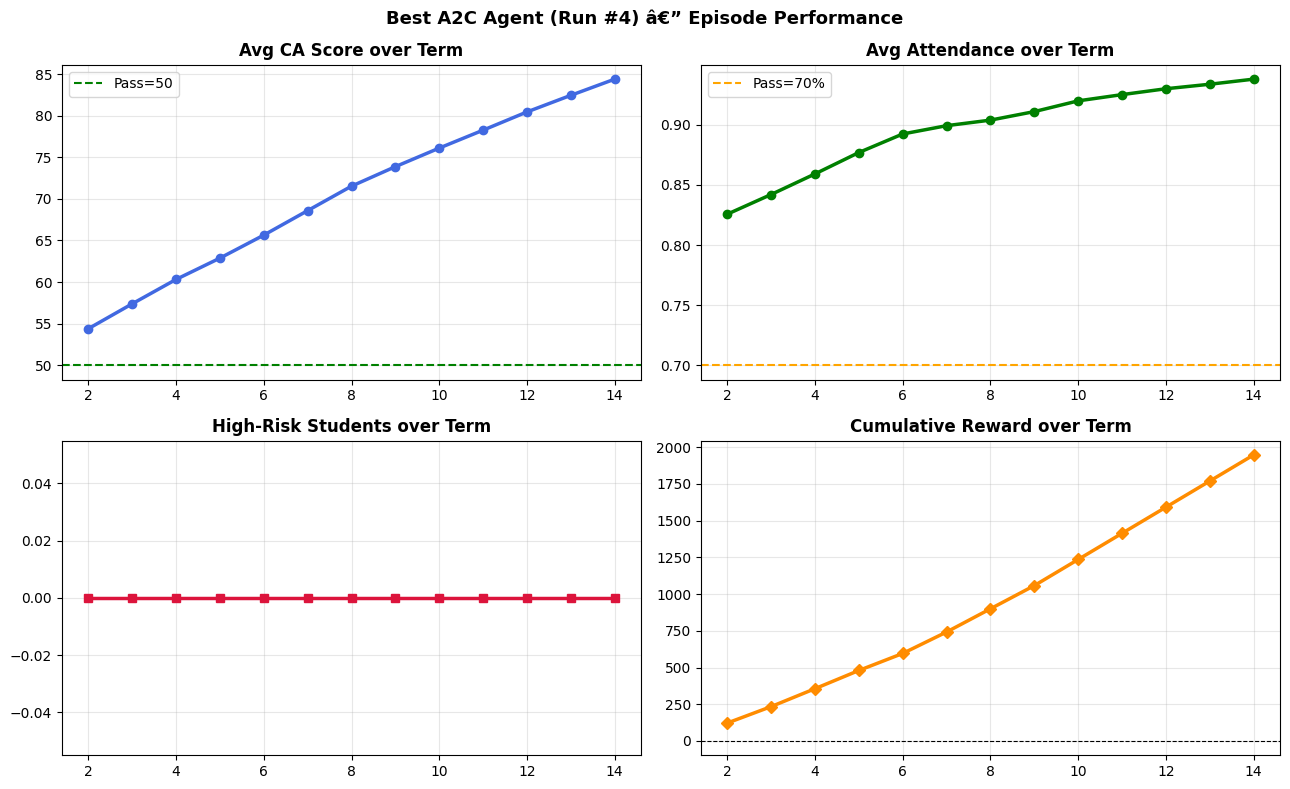

All outputs saved to /kaggle/working/models/
Download via: Kaggle â†’ Output tab â†’ Download


In [19]:
log_df = pd.DataFrame(weekly_log)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(log_df['week'], log_df['avg_ca'], color='royalblue', linewidth=2.5, marker='o')
axes[0,0].axhline(50, color='green', linestyle='--', label='Pass=50'); axes[0,0].legend()
axes[0,0].set_title('Avg CA Score over Term', fontweight='bold'); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(log_df['week'], log_df['avg_att'], color='green', linewidth=2.5, marker='o')
axes[0,1].axhline(0.7, color='orange', linestyle='--', label='Pass=70%'); axes[0,1].legend()
axes[0,1].set_title('Avg Attendance over Term', fontweight='bold'); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(log_df['week'], log_df['high_risk'], color='crimson', linewidth=2.5, marker='s')
axes[1,0].set_title('High-Risk Students over Term', fontweight='bold'); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(log_df['week'], np.cumsum(log_df['reward']), color='darkorange', linewidth=2.5, marker='D')
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,1].set_title('Cumulative Reward over Term', fontweight='bold'); axes[1,1].grid(alpha=0.3)

plt.suptitle(f'Best {best_pg_algo.upper()} Agent (Run #{best_pg_run}) â€” Episode Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK}/models/best_agent_episode.png', dpi=150)
plt.show()
print('All outputs saved to /kaggle/working/models/')
print('Download via: Kaggle â†’ Output tab â†’ Download')